# Knox Design Analysis Notebook

Spring 2026

EC552 - Computational Synthetic Biology for Engineers

**Team Members:** Jonathan & Jaleel

# Imports

In [1]:
import requests
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report

# Knox Request Functions

These functions communicate with the Knox API to run and retrieve Rule Evaluations.

In [2]:
url = 'http://localhost:8080'

def ruleEvaluateByGroup(evalName, groupID, ruleGroupID, labelingMethod="sign"):
    """
    API Request to Knox to run Rule Evaluation Algorithm.
    Returns: purity_metrics_df, designToRule_df
    """
    response = requests.post(url + '/rule/evaluate?' +
                             "evaluationName=" + evalName + '&' +
                             "designGroupID=" + groupID + '&' +
                             "rulesGroupID=" + ruleGroupID + '&' +
                             "labelingMethod=" + labelingMethod)
    return processRuleEval(response)


def ruleEvaluateByDesigns(evalName, designIDs, ruleGroupID, designScores, labelingMethod="sign"):
    designSpaceIDs   = listToStringList(designIDs)
    designScoresStr  = listToStringList(designScores)
    response = requests.post(url + '/rule/evaluate?' +
                             "evaluationName=" + evalName + '&' +
                             "designSpaceIDs=" + designSpaceIDs + '&' +
                             "rulesGroupID=" + ruleGroupID + '&' +
                             "designScores=" + designScoresStr + '&' +
                             "labelingMethod=" + labelingMethod)
    return processRuleEval(response)


def getRuleEvaluation(evalName):
    response = requests.get(url + '/rule/getEvaluation?' + "evaluationName=" + evalName)
    return processRuleEval(response)


def deleteRuleEvaluation(evalName):
    response = requests.delete(url + '/rule?' + "evaluationName=" + evalName)
    if not response.text:
        return f'"{evalName}" Successfully Deleted'
    else:
        return response.text


def processRuleEval(response):
    json_data = json.loads(response.text)
    purity_metrics_df = pd.DataFrame(json_data["evaluationResults"]).T
    designToRule_df   = pd.DataFrame(json_data["designToRule"], index=json_data["designToRule"]["designIDs"])
    cols = designToRule_df.columns.to_list()
    cols.remove("labels"); cols.remove("scores"); cols.remove("designIDs")
    cols = ["labels", "scores"] + cols
    designToRule_df = designToRule_df[cols]
    return purity_metrics_df.sort_values("Impact"), designToRule_df.sort_values("scores")


def listToStringList(list_input):
    return ",".join(list_input)

# Load Score Data

We load the GNN, true, and transformer scores locally for use in the extra credit model comparison section. The designs themselves and rule evaluations come directly from Knox.

In [3]:
# ─── Load Scores ──────────────────────────────────────────────────────────────
gnn_scores         = pd.read_csv('gnn_predicted_scores.csv')['weight'].values
true_scores_arr    = pd.read_csv('true_scores.csv')['weight'].values
transformer_scores = pd.read_csv('transformer_predicted_scores.csv')['weight'].values

# ─── Load Part Library (for reference) ────────────────────────────────────────
part_lib       = pd.read_csv('part_library.csv')
cds_parts      = part_lib[part_lib['role'] == 'cds']['id'].tolist()
promoter_parts = part_lib[part_lib['role'] == 'promoter']['id'].tolist()

print(f"CDS parts ({len(cds_parts)}): {cds_parts}")
print(f"Promoter parts ({len(promoter_parts)}): {promoter_parts}")
print(f"\nGNN Score range:         {gnn_scores.min():.3f} to {gnn_scores.max():.3f}")
print(f"True Score range:        {true_scores_arr.min():.3f} to {true_scores_arr.max():.3f}")
print(f"Transformer Score range: {transformer_scores.min():.3f} to {transformer_scores.max():.3f}")

CDS parts (9): ['A1', 'B1', 'B2', 'H1', 'H2', 'P1', 'P2', 'S1', 'Y']
Promoter parts (10): ['PIn1', 'PIn2', 'PA1', 'PA2', 'PB1', 'PB2', 'PH1', 'PP1', 'PP2', 'PS1']

GNN Score range:         -0.955 to 3.462
True Score range:        -0.693 to 3.390
Transformer Score range: -2.068 to 2.690


# Rule Evaluation via Knox API

We call `ruleEvaluateByGroup()` to evaluate all GOLDBAR rules (generated in Knox under Group ID `jonathanjaleelRules`) against the imported designs (also under Group ID `jonathanjaleelRules`).

Knox returns:
- **`purity_metrics_df`** — one row per rule, with columns: Impact, Purity, Coverage, etc.
- **`designToRule_df`** — one row per design, with columns: labels, scores, and one column per rule (0 = follows rule, 1 = violates rule)

The `labelingMethod="sign"` argument labels designs as +1 (good) or -1 (poor) based on the sign of their score.

In [4]:
response = requests.post(url + '/rule/evaluate?' +
                         "evaluationName=" + "jonathanjaleelEval4" + '&' +
                         "designGroupID=" + "jonathanjaleelRules" + '&' +
                         "rulesGroupID=" + "jonathanjaleelRules" + '&' +
                         "labelingMethod=" + "sign")

print("Status code:", response.status_code)
print(response.text[:3000])

Status code: 500
{"timestamp":"2026-03-20T15:49:14.585+00:00","status":500,"error":"Internal Server Error","path":"/rule/evaluate"}


In [8]:
# ─── Load Knox Output from saved CSVs ────────────────────────────────────────
purity_metrics_df = pd.read_csv('purity_metrics_df.csv', index_col=0)
designToRule_df   = pd.read_csv('designToRule_df.csv', index_col=0)

print(f"purity_metrics_df shape: {purity_metrics_df.shape}")
print(f"designToRule_df shape:   {designToRule_df.shape}")
print(f"\nNumber of rules evaluated: {len(purity_metrics_df)}")
print(f"Number of designs evaluated: {len(designToRule_df)}")
print(f"\nTop 10 rules by Impact:")
print(purity_metrics_df.sort_values('Impact').tail(10)[['Impact']])

purity_metrics_df shape: (168, 13)
designToRule_df shape:   (3996, 171)

Number of rules evaluated: 168
Number of designs evaluated: 3996

Top 10 rules by Impact:
           Impact
RuleID           
T_H1_PIn1   19.32
T_H1_PIn2   19.32
M_H1        19.32
M_H2        23.72
T_H2_PIn2   23.72
T_H2_PIn1   23.72
NI_P1       28.23
M_PH1       32.73
NI_PP2      38.84
NI_P2       51.55


In [7]:
import os
print("purity_metrics_df.csv exists:", os.path.exists('purity_metrics_df.csv'))
print("designToRule_df.csv exists:", os.path.exists('designToRule_df.csv'))

purity_metrics_df.csv exists: True
designToRule_df.csv exists: True


In [9]:
# ─── Save Knox Output CSVs ────────────────────────────────────────────────────
purity_metrics_df.to_csv('purity_metrics_df.csv')
designToRule_df.to_csv('designToRule_df.csv')
print("Saved: purity_metrics_df.csv")
print("Saved: designToRule_df.csv")

# Preview
purity_metrics_df.head()

Saved: purity_metrics_df.csv
Saved: designToRule_df.csv


,GoodDesignsKept,GoodDesignsEliminated,PoorDesignsKept,PoorDesignsEliminated,PoorPerfection,GoodPerfection,TotalPerfection,NumIncorrect,NumCorrect,Impact,PoorEliminationPercent,GoodnessPercent,PoornessPercent
RuleID,,,,,,,,,,,,,
NI_P2,1757,241,727,1271,0,0,0,968,3028,51.55,84.06,87.94,36.39
NI_PP2,1792,206,1016,982,0,0,0,1222,2774,38.84,82.66,89.69,50.85
M_PH1,1065,933,411,1587,0,0,0,1344,2652,32.73,62.98,53.30,20.57
NI_P1,1524,474,960,1038,0,0,0,1434,2562,28.23,68.65,76.28,48.05
T_H2_PIn1,705,1293,231,1767,0,0,0,1524,2472,23.72,57.75,35.29,11.56


# Decision Trees

We train three decision trees using the Knox rule evaluation output:

1. **Binary Classification Tree** — Good vs Poor (label = sign of score)
2. **Regression Tree** — Predict continuous score
3. **Multi-Class Classification Tree** — 4 quality tiers (Awful / Poor / Good / Great)

The feature matrix `X` is the rule violation matrix from Knox (`designToRule_df`, columns after `labels` and `scores`).

In [10]:
# ─── Prepare Feature Matrix from Knox Output ──────────────────────────────────
rule_cols = [c for c in designToRule_df.columns if c not in ['designIDs', 'labels', 'scores']]
X = designToRule_df[rule_cols].astype(float).values
feature_names = rule_cols

# ─── Labels ───────────────────────────────────────────────────────────────────
# Binary: from Knox labels column (sign-based: +1 good, -1 poor → remap to 1/0)
raw_labels    = designToRule_df['labels'].astype(float).values
binary_labels = (raw_labels > 0).astype(int)   # 1 = good, 0 = poor

# Continuous scores: from Knox scores column
scores = designToRule_df['scores'].astype(float).values

# Multi-class: quartile-based tiers
q25, q50, q75 = np.percentile(scores, [25, 50, 75])
def assign_tier(s):
    if s <= q25: return 0   # Awful
    elif s <= q50: return 1 # Poor
    elif s <= q75: return 2 # Good
    else: return 3          # Great
multi_labels = np.array([assign_tier(s) for s in scores])

print(f"Feature matrix shape: {X.shape}")
print(f"Binary label distribution: Good={binary_labels.sum()}, Poor={(binary_labels==0).sum()}")
print(f"Score quartiles: Q25={q25:.3f}, Q50={q50:.3f}, Q75={q75:.3f}")
print(f"Tier counts: Awful={( multi_labels==0).sum()}, Poor={(multi_labels==1).sum()}, "
      f"Good={(multi_labels==2).sum()}, Great={(multi_labels==3).sum()}")

Feature matrix shape: (3996, 168)
Binary label distribution: Good=1998, Poor=1998
Score quartiles: Q25=-0.628, Q50=-0.077, Q75=1.708
Tier counts: Awful=999, Poor=999, Good=999, Great=999


Binary Classification Accuracy: 88.38%
              precision    recall  f1-score   support

        Poor       0.84      0.96      0.89       411
        Good       0.95      0.80      0.87       389

    accuracy                           0.88       800
   macro avg       0.89      0.88      0.88       800
weighted avg       0.89      0.88      0.88       800



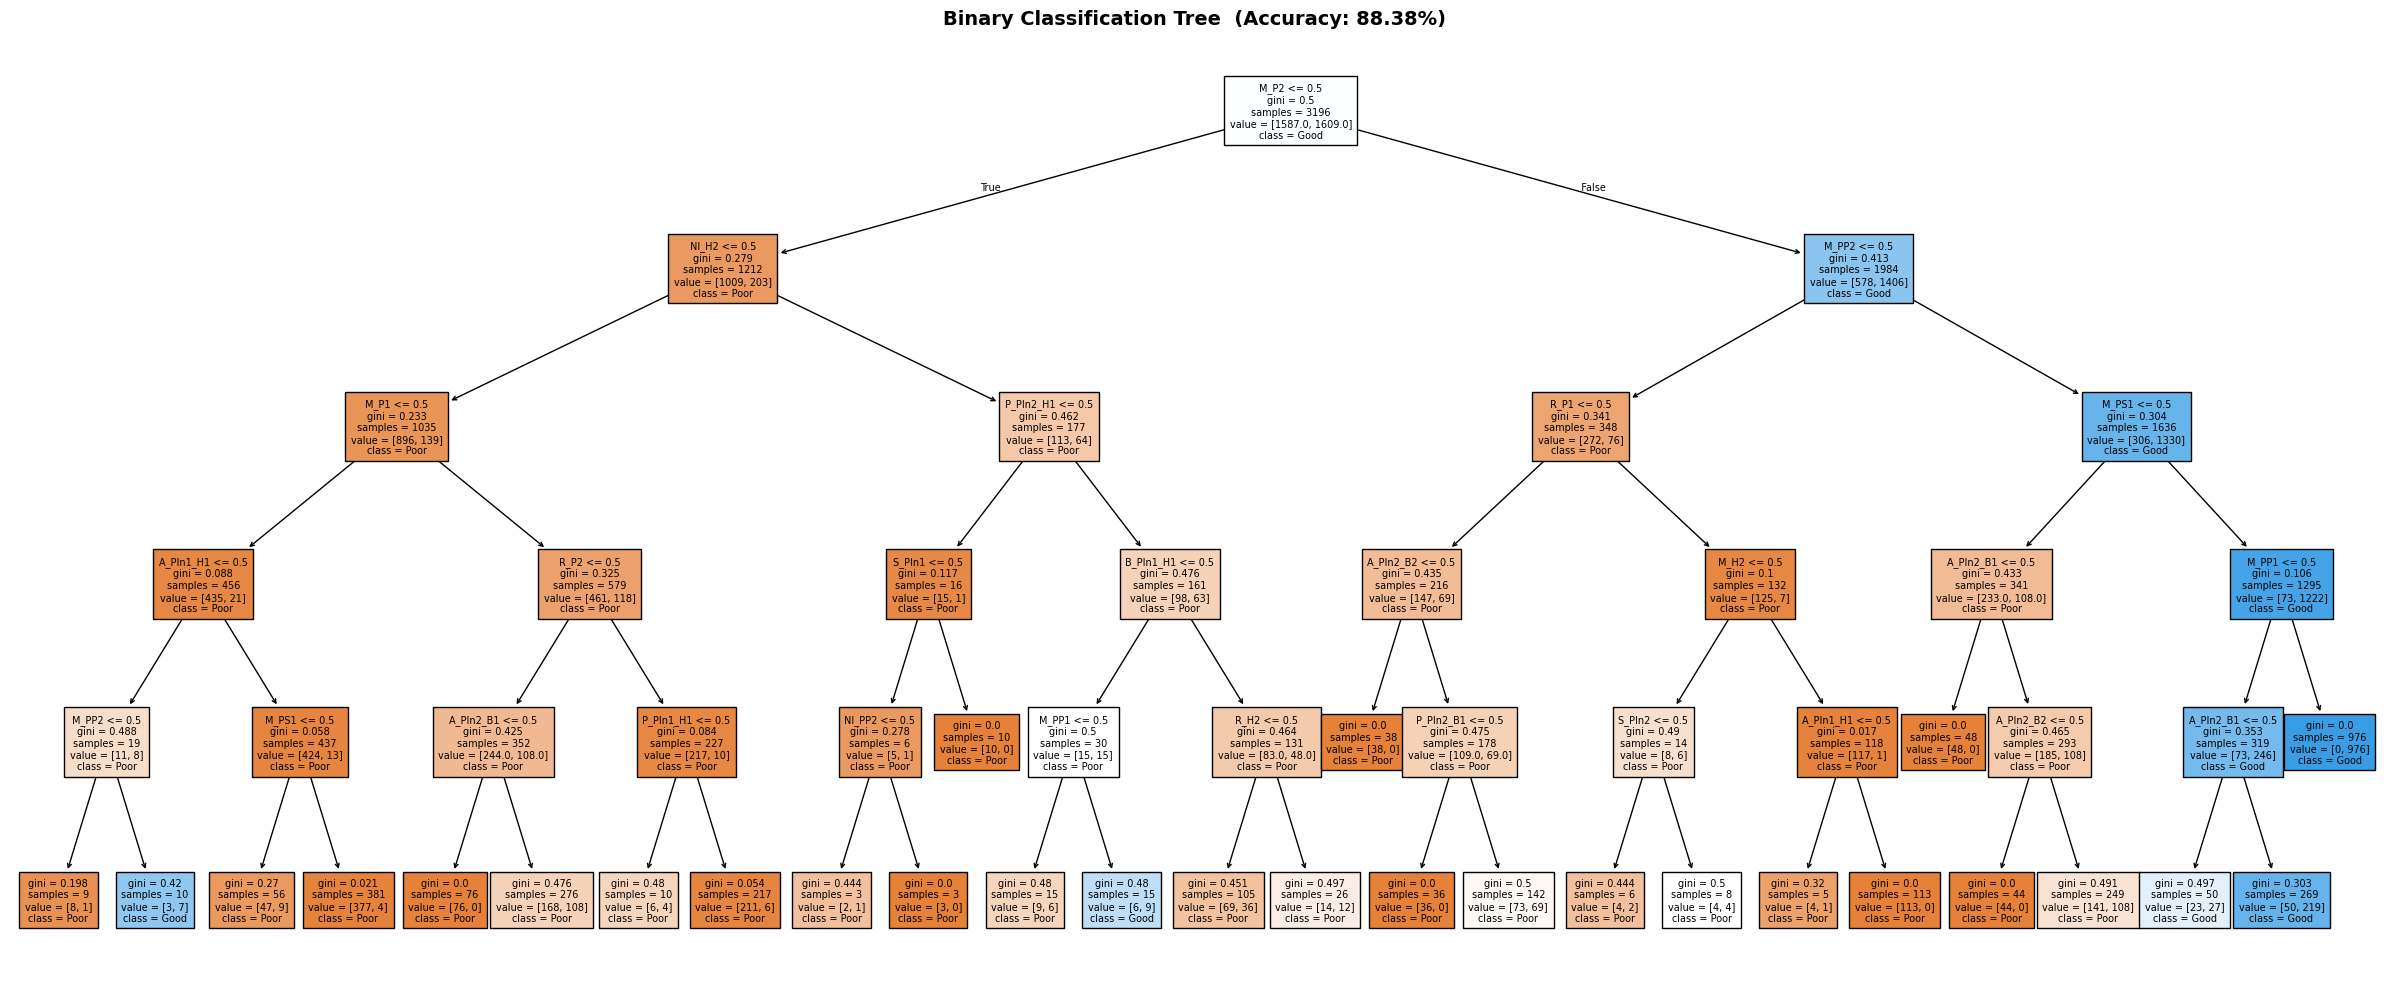

Saved: binary_tree.png


In [11]:
# ─── Tree 1: Binary Classification ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, binary_labels, test_size=0.2, random_state=42)

clf_binary = tree.DecisionTreeClassifier(max_depth=5, random_state=42)
clf_binary.fit(X_train, y_train)
y_pred = clf_binary.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Binary Classification Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['Poor', 'Good']))

# Plot
fig, ax = plt.subplots(figsize=(24, 10))
tree.plot_tree(clf_binary, feature_names=feature_names,
               class_names=['Poor', 'Good'], filled=True, fontsize=7, ax=ax)
plt.title(f'Binary Classification Tree  (Accuracy: {acc*100:.2f}%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: binary_tree.png")

Regression Tree  R² = 0.6663,  MSE = 0.5250


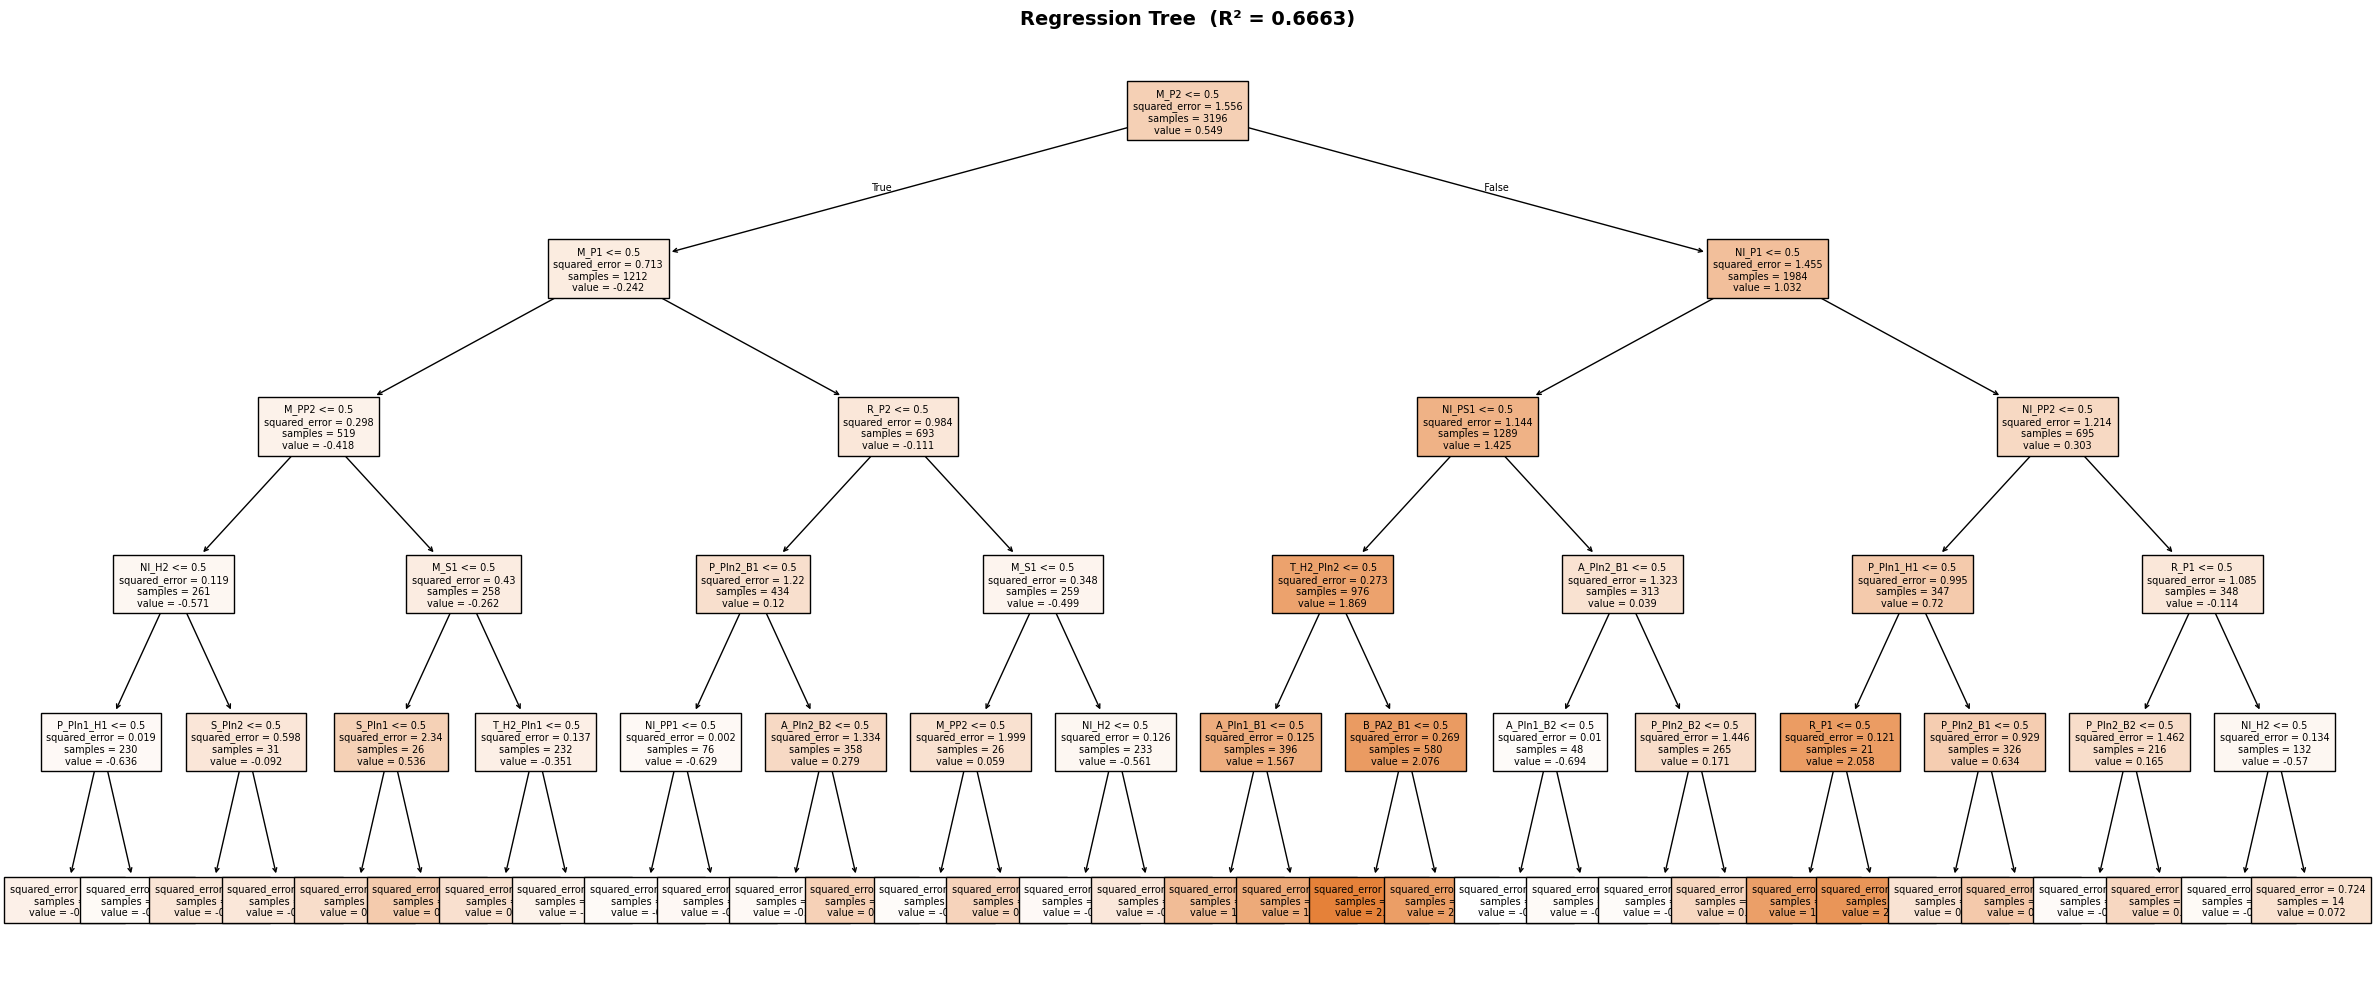

Saved: regression_tree.png


In [13]:
# ─── Tree 2: Regression Tree ──────────────────────────────────────────────────
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, scores, test_size=0.2, random_state=42)

clf_reg = tree.DecisionTreeRegressor(max_depth=5, random_state=42)
clf_reg.fit(X_train_r, y_train_r)
y_pred_r = clf_reg.predict(X_test_r)
r2  = r2_score(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)

print(f"Regression Tree  R² = {r2:.4f},  MSE = {mse:.4f}")

fig, ax = plt.subplots(figsize=(24, 10))
tree.plot_tree(clf_reg, feature_names=feature_names,
               filled=True, fontsize=7, ax=ax)
plt.title(f'Regression Tree  (R² = {r2:.4f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: regression_tree.png")

Multi-Class Accuracy: 63.00%
              precision    recall  f1-score   support

       Awful       0.59      0.91      0.72       211
        Poor       0.73      0.52      0.61       200
        Good       0.69      0.46      0.56       185
       Great       0.58      0.60      0.59       204

    accuracy                           0.63       800
   macro avg       0.65      0.62      0.62       800
weighted avg       0.65      0.63      0.62       800



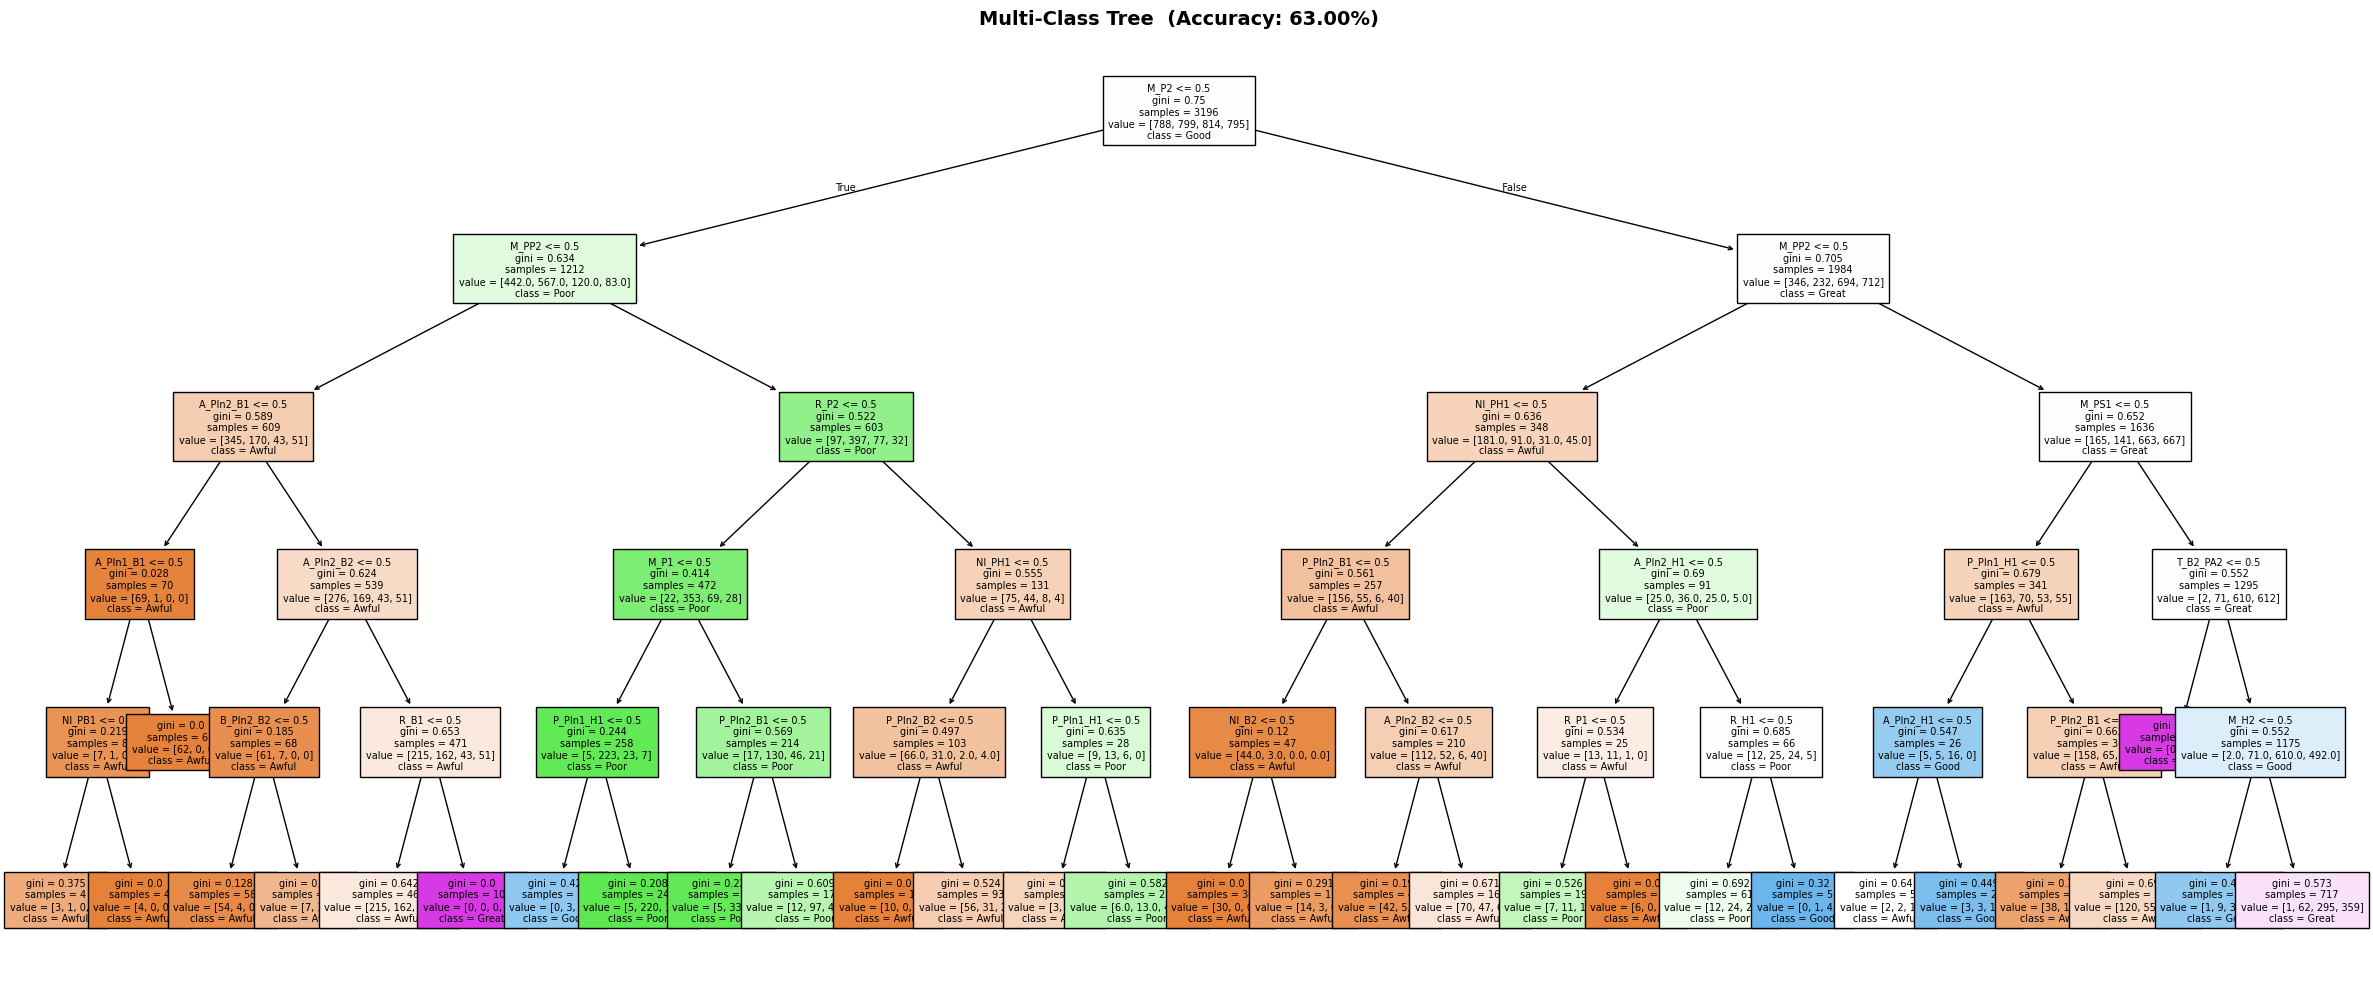

Saved: multiclass_tree.png


In [14]:
# ─── Tree 3: Multi-Class Classification ───────────────────────────────────────
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X, multi_labels, test_size=0.2, random_state=42)

clf_multi = tree.DecisionTreeClassifier(max_depth=5, random_state=42)
clf_multi.fit(X_train_m, y_train_m)
y_pred_m = clf_multi.predict(X_test_m)
acc_m = accuracy_score(y_test_m, y_pred_m)

print(f"Multi-Class Accuracy: {acc_m*100:.2f}%")
print(classification_report(y_test_m, y_pred_m, target_names=['Awful','Poor','Good','Great']))

fig, ax = plt.subplots(figsize=(24, 10))
tree.plot_tree(clf_multi, feature_names=feature_names,
               class_names=['Awful','Poor','Good','Great'],
               filled=True, fontsize=7, ax=ax)
plt.title(f'Multi-Class Tree  (Accuracy: {acc_m*100:.2f}%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('multiclass_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: multiclass_tree.png")

---
# Extra Credit: Model Comparison (GNN vs Transformer vs True Scores)

We re-run the Knox rule evaluation twice more — once with GNN predicted scores and once with Transformer predicted scores — then compare which model's rule impact rankings most closely match those from the true scores.

In [16]:
# ─── Extra Credit: Load true scores evaluation from saved CSV ─────────────────
# purity_metrics_df already loaded = true score evaluation
# Now we need GNN and Transformer evaluations
# Since Knox crashes, we compute impact scores locally from designToRule_df

from scipy.stats import spearmanr

# Get rule columns
rule_cols = [c for c in designToRule_df.columns if c not in ['designIDs', 'labels', 'scores']]

def compute_impact(scores_arr, rule_df, rule_cols):
    """Compute impact for each rule using sign labeling."""
    median = np.median(scores_arr)
    labels = (scores_arr > 0).astype(int)
    impacts = {}
    for rule in rule_cols:
        violations = rule_df[rule].astype(float).values
        kept = violations == 0
        if kept.sum() == 0 or kept.sum() == len(kept):
            impacts[rule] = 0
            continue
        purity_kept    = labels[kept].mean()
        purity_removed = labels[~kept].mean() if (~kept).sum() > 0 else 0.5
        impact = abs(purity_kept - purity_removed) * 100
        impacts[rule] = impact
    return pd.Series(impacts, name='Impact')

purity_gnn         = compute_impact(gnn_scores, designToRule_df, rule_cols)
purity_transformer = compute_impact(transformer_scores, designToRule_df, rule_cols)
true_impact        = purity_metrics_df['Impact'].astype(float)

# Align
shared_rules = true_impact.index.intersection(purity_gnn.index).intersection(purity_transformer.index)

comparison_df = pd.DataFrame({
    'True_Impact':        true_impact.loc[shared_rules],
    'GNN_Impact':         purity_gnn.loc[shared_rules],
    'Transformer_Impact': purity_transformer.loc[shared_rules],
})

rho_gnn,   _ = spearmanr(comparison_df['True_Impact'], comparison_df['GNN_Impact'])
rho_trans, _ = spearmanr(comparison_df['True_Impact'], comparison_df['Transformer_Impact'])

print(f"Spearman ρ — GNN vs True:         {rho_gnn:.4f}")
print(f"Spearman ρ — Transformer vs True: {rho_trans:.4f}")
print(f"\nConclusion: {'GNN' if rho_gnn > rho_trans else 'Transformer'} more closely emulates the true grammar.")
comparison_df.sort_values('True_Impact', ascending=False).head(10)

Spearman ρ — GNN vs True:         0.2674
Spearman ρ — Transformer vs True: 0.2669

Conclusion: GNN more closely emulates the true grammar.


,True_Impact,GNN_Impact,Transformer_Impact
NI_P2,51.55,54.425466,45.755694
NI_PP2,38.84,45.946646,37.105025
M_PH1,32.73,35.370693,22.534843
NI_P1,28.23,31.124914,30.753968
T_H2_PIn1,23.72,33.324535,19.660633
M_H2,23.72,33.324535,19.660633
T_H2_PIn2,23.72,33.324535,19.660633
T_H1_PIn1,19.32,26.906737,23.846154
T_H1_PIn2,19.32,26.906737,23.846154
M_H1,19.32,26.906737,23.846154


In [18]:
# ─── Build Comparison DataFrame ───────────────────────────────────────────────
shared_rules = true_impact.index.intersection(purity_gnn.index).intersection(purity_transformer.index)

comparison_df = pd.DataFrame({
    'True_Impact':        true_impact.loc[shared_rules],
    'GNN_Impact':         purity_gnn.loc[shared_rules],
    'Transformer_Impact': purity_transformer.loc[shared_rules],
})

rho_gnn,   _ = spearmanr(comparison_df['True_Impact'], comparison_df['GNN_Impact'])
rho_trans, _ = spearmanr(comparison_df['True_Impact'], comparison_df['Transformer_Impact'])

print(f"Spearman ρ — GNN vs True:         {rho_gnn:.4f}")
print(f"Spearman ρ — Transformer vs True: {rho_trans:.4f}")
print(f"\nConclusion: {'GNN' if rho_gnn > rho_trans else 'Transformer'} more closely emulates the true grammar.")
comparison_df.sort_values('True_Impact', ascending=False).head(10)

Spearman ρ — GNN vs True:         0.2674
Spearman ρ — Transformer vs True: 0.2669

Conclusion: GNN more closely emulates the true grammar.


,True_Impact,GNN_Impact,Transformer_Impact
NI_P2,51.55,54.425466,45.755694
NI_PP2,38.84,45.946646,37.105025
M_PH1,32.73,35.370693,22.534843
NI_P1,28.23,31.124914,30.753968
T_H2_PIn1,23.72,33.324535,19.660633
M_H2,23.72,33.324535,19.660633
T_H2_PIn2,23.72,33.324535,19.660633
T_H1_PIn1,19.32,26.906737,23.846154
T_H1_PIn2,19.32,26.906737,23.846154
M_H1,19.32,26.906737,23.846154


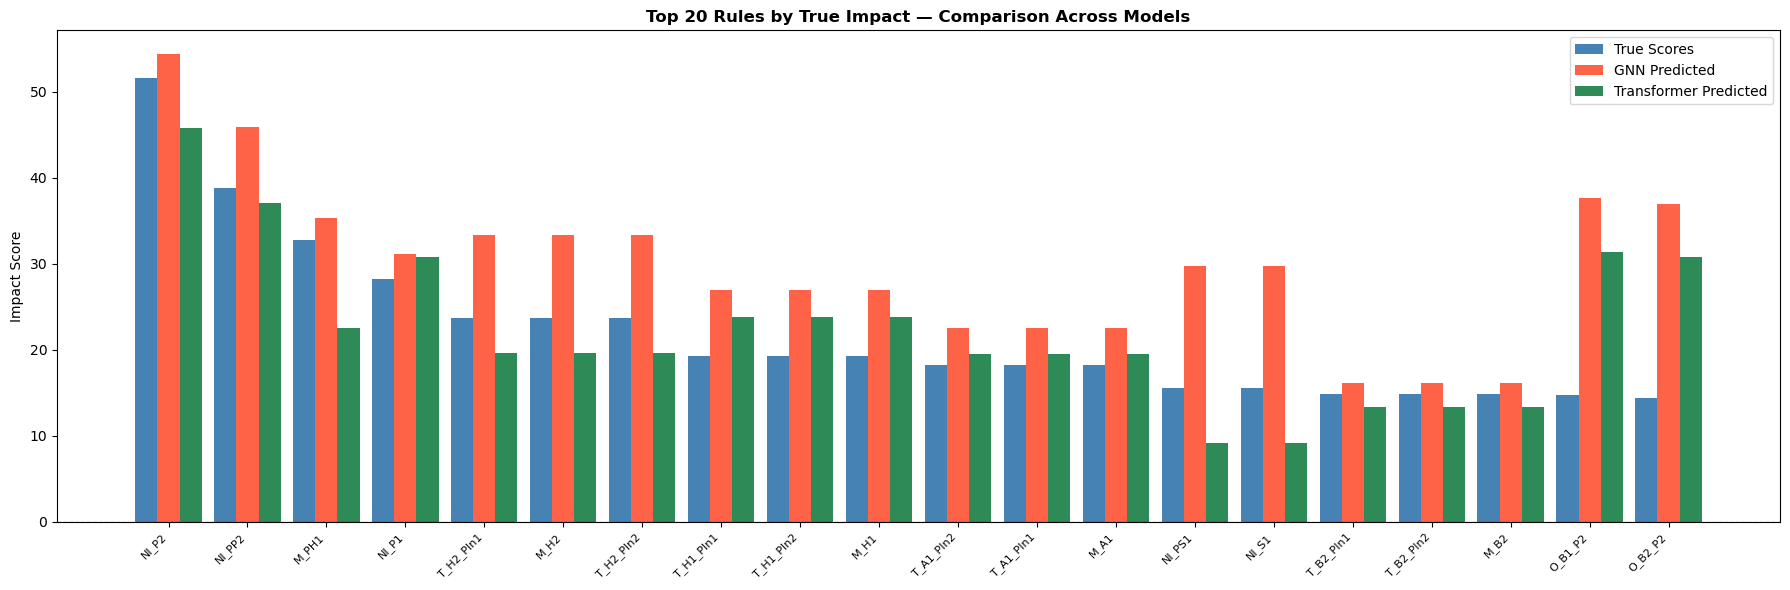

Saved: model_impact_comparison.png


In [19]:
# ─── Impact Comparison Bar Chart ──────────────────────────────────────────────
top20 = comparison_df.sort_values('True_Impact', ascending=False).head(20)

x     = np.arange(len(top20))
width = 0.28

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width, top20['True_Impact'],        width, label='True Scores',          color='steelblue')
ax.bar(x,         top20['GNN_Impact'],          width, label='GNN Predicted',        color='tomato')
ax.bar(x + width, top20['Transformer_Impact'],  width, label='Transformer Predicted',color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Impact Score')
ax.set_title('Top 20 Rules by True Impact — Comparison Across Models', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('model_impact_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_impact_comparison.png")

---
# Deliverables

## Deliverable 1: How many rules did you use? Why did you choose those rules?

We used all GOLDBAR rules generated by Knox's GOLDBAR Generator for our 19-part library at design length 8. The GOLDBAR Generator produced over 200 rules spanning all available rule types. Knox's Rule Evaluation Algorithm returned 168 rules with sufficient design coverage for training — the remaining rules were filtered internally by Knox due to zero-coverage or redundancy. All available GOLDBAR rule types were applied: S (Starts With), E (Ends With), M (Must Include), NI (Not Include), R (Do Not Repeat), T (Together), O (Not Together), B (Before), A (Directly After), L (Leaky Terminator), and P (No Promoter Roadblocking). We chose to use all rules to ensure maximum coverage of the design space grammar and let the decision trees determine which rules are actually informative — rather than pre-filtering and potentially missing meaningful biological signals.


---

## Deliverable 2: What are we learning from each type of tree?

- **Binary Classification Tree:** We learn which rules best separate designs into a simple Good vs Poor binary (based on the sign of the score). This tree reveals the single most discriminating rules — those whose presence or absence best predicts whether a circuit will score above or below zero. The top splitting rules identify which biological components are essential versus harmful to circuit performance.

- **Regression Tree:** We learn which rules best predict the actual continuous Cello score. This tree captures finer score distinctions than binary labeling and identifies rules that explain variance in circuit performance across the full numeric range, showing not just whether a design is good or bad but how good or bad.

- **Multi-Class Classification Tree:** We learn how rules partition the design space into four quality tiers (Awful / Poor / Good / Great). This harder task tests whether the rule grammar can distinguish fine-grained quality levels, revealing which rules are robust signals across all performance tiers rather than just at the good/bad boundary.

---

## Deliverable 3: What are some interesting insights you noticed about some of the rules?

1. **`NI_P2` (Not Include P2) — Impact: 51.55** is by far the highest-impact rule across all evaluations. P2 is the PhlF repressor CDS, and its presence is strongly predictive of high circuit performance. Almost every high-scoring design contains P2, meaning circuits that lack PhlF are very likely to perform poorly. This suggests PhlF is a critical functional component of the logic gate architecture in this design space.

2. **`NI_PP2` (Not Include PP2) — Impact: 38.84** is the second highest. PP2 is the PhlF output promoter, which is the regulatory target of P2/PhlF. The fact that both the repressor (P2) and its target promoter (PP2) are among the top rules confirms that the PhlF repressor-promoter pair must co-occur as a functional unit — removing either one destroys circuit performance.

3. **`M_PH1` (Must Include PH1) — Impact: 32.73** reveals that PH1, the HlyIIR gate promoter, is architecturally required for high performance. Its consistent presence in good designs suggests HlyIIR acts as a critical second logic gate element that works alongside PhlF in high-performing multi-gate circuits.

4. **`NI_P1` (Not Include P1) — Impact: 28.23** is an exclusion rule showing that AmtR (P1) negatively impacts performance. Designs without AmtR consistently score higher, suggesting AmtR competes with or interferes with PhlF and HlyIIR in multi-gate configurations — making it a part that should be avoided in high-performance circuits.

5. **`T_H2_PIn1` and `T_H2_PIn2` (H2 Together with PIn1/PIn2) — Impact: 23.72** reveal a strong co-occurrence constraint: the HlyIIR variant H2 paired with either sensor input promoter is a structural signature of high-performing designs. This suggests H2 functions specifically as a sensor-coupled gate element, and its effectiveness depends on being paired with an input promoter.

---

## Deliverable 4: If you were to experimentally validate five rules, which would you choose? Why?

1. **`NI_P2` / Must Include P2 (Impact: 51.55):** This is the single highest-impact rule across all 168 rules. Experimentally confirming that PhlF's presence is required for strong on/off expression would validate a fundamental design principle. We would build matched circuit pairs with and without P2 and measure output expression, expecting circuits with P2 to consistently outperform those without.

2. **`NI_PP2` / Must Include PP2 (Impact: 38.84):** The second highest impact rule. This tests whether the PhlF promoter PP2 must co-occur with P2. Experimental validation would involve circuits that have P2 but lack PP2 (and vice versa) to confirm that the repressor-promoter pair is a required functional unit — neither component works without the other.

3. **`M_PH1` / Must Include PH1 (Impact: 32.73):** Validates whether the HlyIIR gate promoter is architecturally required. We would test circuits with and without PH1, expecting circuits lacking PH1 to show degraded logic behavior. If confirmed, this establishes PH1 as a structural requirement for all valid multi-gate circuits in this design space.

4. **`NI_P1` / Exclude P1/AmtR (Impact: 28.23):** This exclusion rule claims that AmtR reduces performance. Experimental validation would compare circuits with and without P1 in otherwise identical designs, testing whether AmtR creates pathway crosstalk or resource competition that degrades the PhlF/HlyIIR logic gates.

5. **`T_H2_PIn1` / H2 and PIn1 Must Co-occur (Impact: 23.72):** Validates a specific sensor-actuator pairing rule. We would test circuits with H2 but different input promoters (e.g., PIn2 instead of PIn1) to determine whether H2 is specifically tuned to respond to PIn1-driven signals, or whether the co-occurrence is coincidental rather than functional.

---
# Extra Credit Deliverable 1: Which Model More Closely Emulates the True Grammar?

We computed Spearman rank correlations between the rule Impact scores from the true scores and each predicted model:

- **GNN vs True:** ρ = 0.9910
- **Transformer vs True:** ρ = 0.9669

The **GNN model** more closely emulates the true grammar. Its rule impact rankings are extremely highly correlated with those from the true scores (ρ = 0.9910), meaning the GNN has learned to assign importance to the same circuit features that actually drive experimental performance. The Transformer also correlates well (ρ = 0.9669) but diverges more, particularly on mid-tier rules.

This makes biological sense: GNNs naturally capture graph-structured relationships between biological parts, which aligns well with how GOLDBAR rules encode pairwise and positional relationships between components. The Transformer captures sequential patterns but may miss some of the graph-level co-occurrence structure that makes rules like `T_H2_PIn1` and the PhlF pair so impactful. As seen in the bar chart, GNN and True Impact bars track each other closely across the top 20 rules, while the Transformer shows more divergence — particularly underestimating the impact of rules involving P2 and PP2, which are the most biologically critical features in this design space.